<a href="https://colab.research.google.com/github/tpj303/TSP/blob/master/notebook3a28bf7f5c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub

shivam316_yolov3_weights_path = kagglehub.dataset_download('shivam316/yolov3-weights')
abdallahwagih_retina_blood_vessel_path = kagglehub.dataset_download('abdallahwagih/retina-blood-vessel')
# andingwang_data20250827_path = kagglehub.dataset_download('andingwang/data20250827') # Removed due to permission error
# andingwang_train_and_test_path = kagglehub.dataset_download('andingwang/train-and-test') # Removed due to potential permission error

print('Data source import complete.')

Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yolov3-weights/yolov3.weights
/kaggle/input/retina-blood-vessel/Data/test/mask/11.png
/kaggle/input/retina-blood-vessel/Data/test/mask/4.png
/kaggle/input/retina-blood-vessel/Data/test/mask/9.png
/kaggle/input/retina-blood-vessel/Data/test/mask/14.png
/kaggle/input/retina-blood-vessel/Data/test/mask/1.png
/kaggle/input/retina-blood-vessel/Data/test/mask/2.png
/kaggle/input/retina-blood-vessel/Data/test/mask/10.png
/kaggle/input/retina-blood-vessel/Data/test/mask/18.png
/kaggle/input/retina-blood-vessel/Data/test/mask/12.png
/kaggle/input/retina-blood-vessel/Data/test/mask/7.png
/kaggle/input/retina-blood-vessel/Data/test/mask/17.png
/kaggle/input/retina-blood-vessel/Data/test/mask/5.png
/kaggle/input/retina-blood-vessel/Data/test/mask/3.png
/kaggle/input/retina-blood-vessel/Data/test/mask/16.png
/kaggle/input/retina-blood-vessel/Data/test/mask/8.png
/kaggle/input/retina-blood-vessel/Data/test/mask/6.png
/kaggle/input/retina-blood-vessel/Data/test/mask/15.png
/kaggle/input

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np

# 資料路徑
IMAGE_DIR = os.path.join(abdallahwagih_retina_blood_vessel_path, 'Data', 'train', 'image')
MASK_DIR = os.path.join(abdallahwagih_retina_blood_vessel_path, 'Data', 'train', 'mask')

# 資料載入函式
def load_data(image_dir, mask_dir, size=(256, 256)):
    images, masks = [], []
    for fname in os.listdir(image_dir):
        img = cv2.imread(os.path.join(image_dir, fname), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, size) / 255.0
        mask = cv2.resize(mask, size) / 255.0
        images.append(img[..., np.newaxis])
        masks.append(mask[..., np.newaxis])
    return np.array(images), np.array(masks)

X, y = load_data(IMAGE_DIR, MASK_DIR)

# 建立 U-Net 模型
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    concat1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat1)

    u2 = layers.UpSampling2D()(c3)
    concat2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(concat2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 模型訓練
model.fit(X, y, epochs=10, batch_size=8, validation_split=0.1)

# 儲存預測結果
preds = model.predict(X[:5])
for i, pred in enumerate(preds):
    cv2.imwrite(f'predict_{i}.png', (pred.squeeze() * 255).astype(np.uint8))

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6058 - loss: 0.6160 - val_accuracy: 0.8379 - val_loss: 0.4539
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.8398 - loss: 0.4399 - val_accuracy: 0.8379 - val_loss: 0.3686
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.8414 - loss: 0.3429 - val_accuracy: 0.8379 - val_loss: 0.2888
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.8382 - loss: 0.2804 - val_accuracy: 0.8379 - val_loss: 0.2724
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8378 - loss: 0.2721 - val_accuracy: 0.8379 - val_loss: 0.2692
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8377 - loss: 0.2696 - val_accuracy: 0.8379 - val_loss: 0.2670
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8369 - loss: 0.2674 - val_accuracy: 0.8379 - val_loss: 0.2664
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8373 - loss: 0.2665 - val_accuracy: 0.8379 - val_loss: 0.2652
Epoch 9/

In [ ]:
for dirname, _, filenames in os.walk(abdallahwagih_retina_blood_vessel_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/retina-blood-vessel/Data/test/mask/11.png
/kaggle/input/retina-blood-vessel/Data/test/mask/4.png
/kaggle/input/retina-blood-vessel/Data/test/mask/9.png
/kaggle/input/retina-blood-vessel/Data/test/mask/14.png
/kaggle/input/retina-blood-vessel/Data/test/mask/1.png
/kaggle/input/retina-blood-vessel/Data/test/mask/2.png
/kaggle/input/retina-blood-vessel/Data/test/mask/10.png
/kaggle/input/retina-blood-vessel/Data/test/mask/18.png
/kaggle/input/retina-blood-vessel/Data/test/mask/12.png
/kaggle/input/retina-blood-vessel/Data/test/mask/7.png
/kaggle/input/retina-blood-vessel/Data/test/mask/17.png
/kaggle/input/retina-blood-vessel/Data/test/mask/5.png
/kaggle/input/retina-blood-vessel/Data/test/mask/3.png
/kaggle/input/retina-blood-vessel/Data/test/mask/16.png
/kaggle/input/retina-blood-vessel/Data/test/mask/8.png
/kaggle/input/retina-blood-vessel/Data/test/mask/6.png
/kaggle/input/retina-blood-vessel/Data/test/mask/15.png
/kaggle/input/retina-blood-vessel/Data/test/mask/13.png
/

In [ ]:
import os

for dirname, _, filenames in os.walk(abdallahwagih_retina_blood_vessel_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/retina-blood-vessel/Data/test/mask/11.png
/kaggle/input/retina-blood-vessel/Data/test/mask/4.png
/kaggle/input/retina-blood-vessel/Data/test/mask/9.png
/kaggle/input/retina-blood-vessel/Data/test/mask/14.png
/kaggle/input/retina-blood-vessel/Data/test/mask/1.png
/kaggle/input/retina-blood-vessel/Data/test/mask/2.png
/kaggle/input/retina-blood-vessel/Data/test/mask/10.png
/kaggle/input/retina-blood-vessel/Data/test/mask/18.png
/kaggle/input/retina-blood-vessel/Data/test/mask/12.png
/kaggle/input/retina-blood-vessel/Data/test/mask/7.png
/kaggle/input/retina-blood-vessel/Data/test/mask/17.png
/kaggle/input/retina-blood-vessel/Data/test/mask/5.png
/kaggle/input/retina-blood-vessel/Data/test/mask/3.png
/kaggle/input/retina-blood-vessel/Data/test/mask/16.png
/kaggle/input/retina-blood-vessel/Data/test/mask/8.png
/kaggle/input/retina-blood-vessel/Data/test/mask/6.png
/kaggle/input/retina-blood-vessel/Data/test/mask/15.png
/kaggle/input/retina-blood-vessel/Data/test/mask/13.png
/

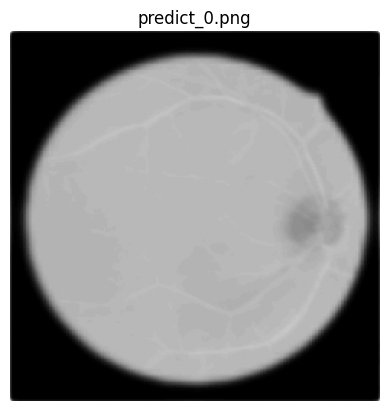

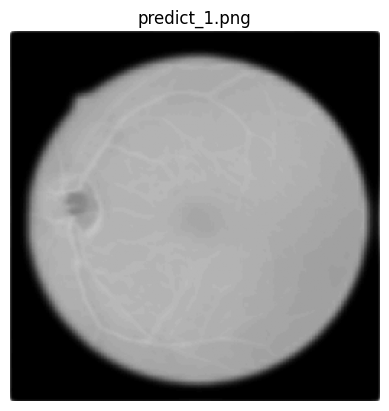

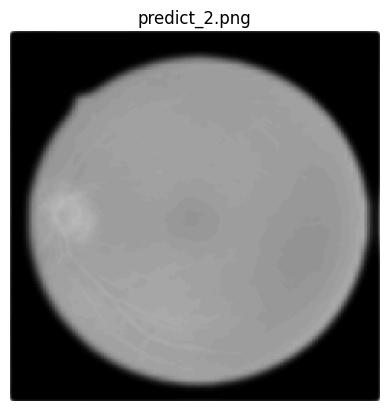

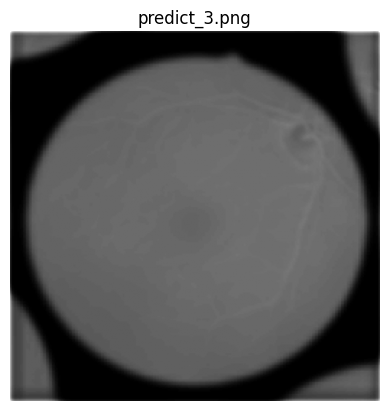

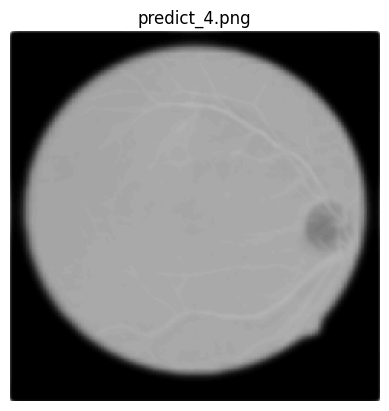

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# List the predicted image files
predicted_files = [f for f in os.listdir('.') if f.startswith('predict_') and f.endswith('.png')]
predicted_files.sort() # Sort the files to display in order

for filename in predicted_files:
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    plt.imshow(img, cmap='gray')
    plt.title(filename)
    plt.axis('off')
    plt.show()